In [7]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import numpy as np

font_path = font_manager.findfont(font_manager.FontProperties(family='Arial'))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = [font_path]
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# there are some legit errors in reading the manual stoch, eg when someone reports A2B2 for tetramer (presumably they have some sort of symmstry pairs), but manual check indicate the counting was correct

In [3]:
stoch_df = pd.read_csv('casp16_rna_stochi.txt',delim_whitespace=True)
stoch_df['target'] = stoch_df.model.str[:5]
print(stoch_df.head())
gt_num_chains = {'R0250':6,
                'R0251':14,
                'R0252':6,
                'R0253':8,
                'R0254':14,
                'R0281':2,
                'R0283':8, # techincally can be 1 and 2 as well
                'R0285':2,
                'R0290':2}
stoch_df = stoch_df.sort_values('target')

           model  num_chains target
0  R0250TS028_1o           3  R0250
1  R0250TS028_2o           3  R0250
2  R0250TS028_3o           3  R0250
3  R0250TS028_4o           3  R0250
4  R0250TS110_1o           3  R0250


C:\Users\racha\AppData\Local\Temp\ipykernel_10068\3202537062.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  stoch_df = pd.read_csv('casp16_rna_stochi.txt',delim_whitespace=True)


In [4]:
def category_value_line_plot(df, category_col, value_col,figsize=(2,2),colored=None,ylabel='',values=None,ax=None):
    # Calculate counts for each category-value combination
    counts = df.groupby([category_col, value_col]).size().reset_index(name='count')
    # Get unique categories and values
    categories = counts[category_col].unique()
    x_positions = np.arange(len(categories))
    category_map = dict(zip(categories, x_positions))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize) 

    if values is None:
        values = counts[value_col].unique()
        value_dict = {i:i for i in values}
    else:
        value_dict = {v:i for i,v in enumerate(values)}        

    # Define a width for the horizontal bars
    bar_width = 1/counts['count'].max()

    for _, row in counts.iterrows():
        x_pos = category_map[row[category_col]]
        xmin = x_pos - (bar_width * row['count'])/2
        xmax = xmin + (bar_width * row['count'])
        if colored is None:
            ax.hlines(value_dict[row[value_col]], xmin, xmax, linewidth=3,color='black')
        else:
            #print(row)
            if row[value_col] == colored[row[category_col]] or  (row[category_col]=='R0283' and row[value_col] in [1,4,8]):
                ax.hlines(value_dict[row[value_col]], xmin, xmax, linewidth=3,color='blue')
            else:
                ax.hlines(value_dict[row[value_col]], xmin, xmax, linewidth=3,color='black')
    # Set x-axis ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories,size=8)
    ax.set_xlabel('Target',size=8)
    ax.set_ylabel(ylabel,size=8)

    ax.set_yticks(list(value_dict.values()))
    ax.set_yticklabels(value_dict.keys(),size=8)
    
    return ax


In [5]:
gt_num_chains

{'R0250': 6,
 'R0251': 14,
 'R0252': 6,
 'R0253': 8,
 'R0254': 14,
 'R0281': 2,
 'R0283': 8,
 'R0285': 2,
 'R0290': 2}

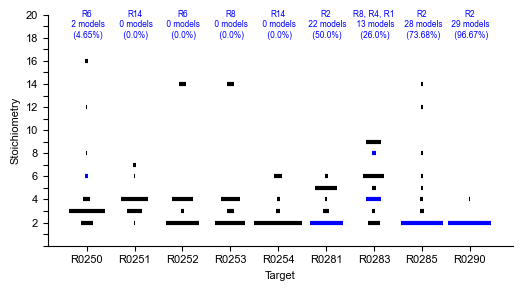

In [8]:
g=category_value_line_plot(stoch_df,"target","num_chains",figsize=(6,3),colored=gt_num_chains,ylabel='Stoichiometry')
for i,(target,gt) in enumerate(gt_num_chains.items()):
    if target != 'R0283':
        num_gt = ((stoch_df.target==target)&(stoch_df.num_chains==gt)).sum()
        num_total = (stoch_df.target==target).sum()
        #g.hlines(gt,i-0.3,i+0.3,"blue",linewidth=2)
        g.text(i,18,f'R{gt}\n {num_gt} models\n ({round(100*num_gt/num_total,2)}%)',
                           ha='center',size=6,color='blue')
    else:
        num_gt = ((stoch_df.target==target)&(stoch_df.num_chains.isin([1,4,8]))).sum()
        num_total = (stoch_df.target==target).sum()
        #g.hlines(gt,i-0.3,i+0.3,"blue",linewidth=2)
        g.text(i,18,f'R8, R4, R1\n {num_gt} models\n ({round(100*num_gt/num_total,2)}%)',
                           ha='center',size=6,color='blue')
g.set_ylim(0,20)
g.spines['top'].set_visible(False)
g.spines['right'].set_visible(False)
g.set_yticks(range(21)) 
t=g.set_yticklabels([str(i) if i % 2 == 0 and i!=0 else "" for i in range(21)])
plt.savefig(f"stoichometry.svg",dpi=400, bbox_inches='tight', transparent=True)

In [9]:
sym_df = pd.read_csv('casp16_sym_round1_rna-homomultimers.csv',na_values=[' '])
sym_df['target'] = sym_df.model.apply(lambda z: z.split('TS')[0])

# technically should check axis of smaller symmetries to confirm they are indeed subset...
def get_highest_symettry(row,rmsd_cutoff=10):
    if row.symmetries != row.symmetries:
        return 'c1'
    syms = row.symmetries.split()
    rmsds = row.rmsds.split()
    val_syms = [s for s,r in zip(syms,rmsds) if float(r)<rmsd_cutoff]
    current_highest_sym = 'c1'
    for sym in val_syms:
        if int(sym[1:]) > int(current_highest_sym[1:]):
            current_highest_sym = sym
        elif int(sym[1:]) == int(current_highest_sym[1:]) and sym[0] == 'd':
            current_highest_sym = sym
    return current_highest_sym

sym_df['sym'] = sym_df.apply(get_highest_symettry,axis=1)
sym_order = ['d7' ,'c14','c7','d4', 'c8', 'd3','c6', 'd2', 'c4' ,'c3','c2','c1'][::-1]
#sym_df['sym'] = sym_df.sym.astype("category")
#sym_df['sym'] = sym_df.sym.cat.set_categories(sym_order)
sym_df = sym_df.sort_values(['sym','target'])
target_order = ['R1250', 'R1251', 'R1252', 'R1253v1', 'R1253v2', 'R1254', 'R1281', 'R1283v2',
 'R1283v3', 'R1285', 'R1290']
# TODO check what is reasonable cutoff
sym_df.to_csv('casp16_rnamultimer_sym_round1.csv',index=False)

In [10]:
sym_df.head()

,model,symmetries,rmsds,target,sym
0,R1250TS028_1o_simple,NaN,NaN,R1250,c1
1,R1250TS028_2o_simple,NaN,NaN,R1250,c1
2,R1250TS028_3o_simple,NaN,NaN,R1250,c1
3,R1250TS028_4o_simple,NaN,NaN,R1250,c1
4,R1250TS028_5o_simple,NaN,NaN,R1250,c1


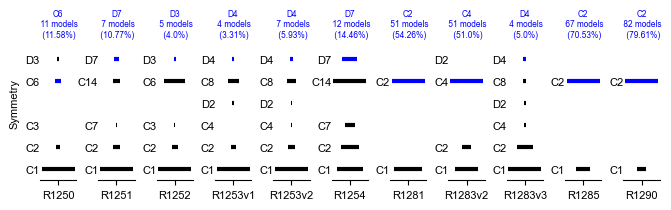

In [11]:
# D, highest C, other C, C1
sym_options={'R1250': ['d3',   'c6','', 'c3','c2',        'c1'],
'R1251': ['d7',  'c14','','c7','c2',       'c1'],
'R1252': ['d3',   'c6', '','c3','c2',        'c1'],
'R1253v1':['d4',   'c8','d2', 'c4','c2',  'c1'],
'R1253v2':['d4',   'c8','d2', 'c4','c2',  'c1'],
'R1254':['d7',  'c14','','c7','c2',       'c1'],
'R1281':['',     'c2','','','',        'c1'],
'R1283v2':['d2', 'c4','','','c2',  'c1'],
'R1283v3':['d4',   'c8','d2', 'c4','c2',  'c1'],
'R1285':['',      'c2','','','',        'c1'],
'R1290':['',      'c2','','','',        'c1']}
refsyms = {'R1250':'c6',
        'R1251':'d7',
        'R1252':'d3',
        'R1253v1':'d4', 
        'R1253v2':'d4', 
        'R1254':'d7', 
        'R1281':'c2',
        'R1283v2':'c4',
        'R1283v3':'d4', 
        'R1285':'c2', 
        'R1290':'c2'}
fig,axes = plt.subplots(1,len(refsyms),figsize=(8,2))
for i,(target,sym_opt) in enumerate(sym_options.items()):
    num_gt = ((sym_df.target==target)&(sym_df.sym==refsyms[target])).sum()
    num_total = (sym_df.target==target).sum()


    
    g = category_value_line_plot(sym_df[sym_df.target==target], 'target', 'sym',figsize=(2,2),ylabel=''if i!= 0 else 'Symmetry',
                                 values=sym_opt[::-1],colored=refsyms,ax=axes[i])
    g.axes.text(0,6,
                       f'{refsyms[target].upper()}\n {num_gt} models\n ({round(100*num_gt/num_total,2)}%)',
                       ha='center',size=6,color='blue')
    g.spines[['top','right','left']].set_visible(False)
    g.tick_params(axis='y', which='both', length=0,pad=0)
    g.set_yticklabels([x.get_text().upper() for x in g.get_yticklabels()])
    g.set_ylim(-0.5,6.5)
    g.set_xlabel('')
plt.subplots_adjust(wspace=0.6)
plt.savefig(f"symmetry.svg",dpi=400, bbox_inches='tight', transparent=True)

In [13]:
rna_hybrid_results_f = '../RNA_hybrid_results_table.csv'
df_hybrid = pd.read_csv(rna_hybrid_results_f,
                 delim_whitespace=True,
                 usecols=range(21),
                na_values=['-'],
                index_col=False)
MULTIMER_METRICS = {'lddt':'max','tm_score':'max','gdt_ts':'max',
           'TM_align':'max',
          'global_rmsd':'min','clashes_number':'min',
                   'ICS(F1)':max, 
                    'Prec.Iface':max, 
                    'Recal.Iface':max, 
                    'IPS':max, 
                    'QSglob':max, 
                    'QSbest':max, 
                    'ilDDT':max, 
                    'GlobDockQ':max, 
                    'BestDockQ':max}
col_rename = {'#Model':'model','Gr.Code':'gr_code',
'RMSD':'global_rmsd','lDDT':'lddt',  
 'TMscore':'tm_score','GDT_TS':'gdt_ts',  
'MDL.Clash':'clashes_number','TMalign':'TM_align'}
# read the group information
gr_dict = pd.read_csv('../CASP16_Groups.csv')
gr_dict['gr_code'] = gr_dict['Group number'].apply(lambda x: '0'*(3-len(str(x)))+str(x))
gr_dict['final_name'] = gr_dict.apply(lambda x: x['Group Name'] + ' - ' + x['gr_code'], axis=1)
gr_code_to_name = gr_dict.set_index('gr_code').final_name.to_dict()
gr_dict = gr_dict.set_index('gr_code')['Group Name'].to_dict()


df_hybrid.rename(columns=col_rename,inplace=True)
df_hybrid['target'] = df_hybrid.model.apply(lambda x: x.split('TS')[0])
df_hybrid = df_hybrid.astype({z:float for z in MULTIMER_METRICS.keys()})
df_hybrid['gr_code'] = df_hybrid.gr_code.apply(lambda x: x[:-1] if 's' in x else x)
df_hybrid['gr_code_'] = df_hybrid.gr_code.copy()

df_hybrid['gr_code'] = df_hybrid.gr_code.apply(lambda x: gr_dict[x] + ' - ' + x if x in gr_dict else x)

print(df_hybrid.dtypes,len(df_hybrid))
df_hybrid.head()

model              object
gr_code            object
ICS(F1)           float64
Prec.Iface        float64
Recal.Iface       float64
IPS               float64
QSglob            float64
QSbest            float64
lddt              float64
ilDDT             float64
gdt_ts            float64
global_rmsd       float64
tm_score          float64
TM_align          float64
GlobDockQ         float64
BestDockQ         float64
Mol.Size            int64
Stoich.            object
MDL.Conts           int64
REF.Conts           int64
clashes_number    float64
target             object
gr_code_           object
dtype: object 2497


C:\Users\racha\AppData\Local\Temp\ipykernel_10068\541716976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_hybrid = pd.read_csv(rna_hybrid_results_f,


,model,gr_code,ICS(F1),Prec.Iface,Recal.Iface,IPS,QSglob,QSbest,lddt,ilDDT,...,TM_align,GlobDockQ,BestDockQ,Mol.Size,Stoich.,MDL.Conts,REF.Conts,clashes_number,target,gr_code_
0,M0276TS369_1,Bhattacharya - 369,0.847,0.900,0.800,0.933,0.786,0.804,0.863,0.413,...,0.965,0.562,0.562,2,(A1p)(B1d),42,45,2.0,M0276,369
1,M0276TS262_4,CoDock - 262,0.805,0.833,0.778,0.903,0.515,0.766,0.861,0.440,...,0.971,0.578,0.578,3,(A2p)(B1d),80,45,0.0,M0276,262
2,M0276TS272_1,GromihaLab - 272,0.790,0.889,0.711,0.812,0.352,0.848,0.872,0.489,...,0.981,0.548,0.548,3,(A2p)(B1d),113,45,13.0,M0276,272
3,M0276TS462_2,Zheng - 462,0.635,0.675,0.600,0.781,0.816,0.829,0.864,0.425,...,0.973,0.471,0.471,2,(A1p)(B1d),41,45,3.0,M0276,462
4,M0276TS110_2,MIEnsembles-Server - 110,0.635,0.675,0.600,0.781,0.816,0.829,0.864,0.425,...,0.973,0.471,0.471,2,(A1p)(B1d),41,45,3.0,M0276,110


In [14]:
df_hybrid.target.unique()

array(['M0276', 'M0287', 'M1209', 'M1211', 'M1212', 'M1216', 'M1221',
       'M1224', 'M1228v1', 'M1228v2', 'M1239v1', 'M1239v2', 'M1268',
       'M1271', 'M1276', 'M1282', 'M1287', 'M1293', 'M1296', 'M1297'],
      dtype=object)

In [15]:
correct_hybrid = {'276':'(A1p)(B1d)','287':"(A2p)(B2d)"} # '268':'',A8B8C8D8E1F1
hybrid_sto_count = df_hybrid[df_hybrid.target.str[-3:].isin(['268','268v1','276','287'])].groupby('target')['Stoich.'].value_counts()
# TODO just ignoring 268 for now because of confusion
# stochiometry really isn't that interesting 
# lets not make a plot but
for t, st in correct_hybrid.items():
    total_pred = hybrid_sto_count[f"M0{t}"].sum()
    correct_pred = hybrid_sto_count[f"M0{t}"][st]
    print(correct_pred/total_pred,correct_pred,total_pred)
    # probably should ignore no dna targets
    nodna_pred = hybrid_sto_count[f"M0{t}"][f'{st[:5]}(B0)']
    print(correct_pred/(total_pred-nodna_pred),correct_pred/total_pred,correct_pred,nodna_pred,total_pred)
# 287 and 268 could be added to round 0 protein-protein
# our dna-protein not has intersting
# 276 will be interesting for us so we can comment on round 0 but not rank 
hybrid_sto_count

0.4580152671755725 60 131
0.6 0.4580152671755725 60 31 131
0.23387096774193547 29 124
0.3118279569892473 0.23387096774193547 29 31 124


target  Stoich.              
M0276   (A1p)(B1d)                60
        (A1p)(B0)                 31
        (A2p)(B1d)                 7
        (A20p)(B20d)               6
        (A2p)(B2d)                 6
        (A4p)(B2d)                 5
        (A4p)(B1d)                 3
        (A8p)(B1d)                 3
        (A5p)(B1d)                 2
        (A6p)(B1d)                 2
        (A7p)(B1d)                 2
        (A10p)(B10d)               1
        (A12p)(B12d)               1
        (A16p)(B16d)               1
        (A18p)(B18d)               1
M0287   (A1p)(B1d)                32
        (A2p)(B0)                 31
        (A2p)(B1d)                30
        (A2p)(B2d)                29
        (A4p)(B2d)                 2
M1268   (A16p)(B18d)(C0)          57
        (A8p)(B8p)(C10d)(D8r)     57
        (A16p)(B0)(C0)             6
        (A8p)(B8p)(C0)(D0)         6
        (A2p)(B2p)(C3d)(D0)        5
        (A4p)(B3d)(C0)             5
        

In [16]:
hybrid_sto_count

target  Stoich.              
M0276   (A1p)(B1d)                60
        (A1p)(B0)                 31
        (A2p)(B1d)                 7
        (A20p)(B20d)               6
        (A2p)(B2d)                 6
        (A4p)(B2d)                 5
        (A4p)(B1d)                 3
        (A8p)(B1d)                 3
        (A5p)(B1d)                 2
        (A6p)(B1d)                 2
        (A7p)(B1d)                 2
        (A10p)(B10d)               1
        (A12p)(B12d)               1
        (A16p)(B16d)               1
        (A18p)(B18d)               1
M0287   (A1p)(B1d)                32
        (A2p)(B0)                 31
        (A2p)(B1d)                30
        (A2p)(B2d)                29
        (A4p)(B2d)                 2
M1268   (A16p)(B18d)(C0)          57
        (A8p)(B8p)(C10d)(D8r)     57
        (A16p)(B0)(C0)             6
        (A8p)(B8p)(C0)(D0)         6
        (A2p)(B2p)(C3d)(D0)        5
        (A4p)(B3d)(C0)             5
        

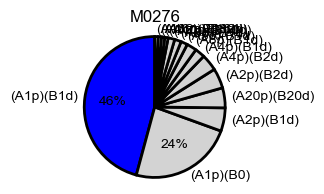

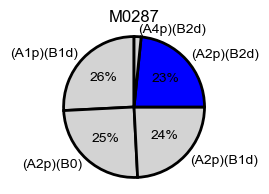

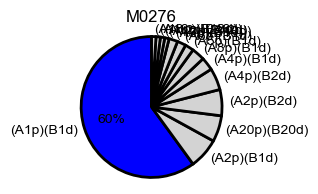

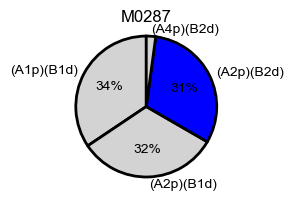

In [17]:
grouped = hybrid_sto_count.rename('count').reset_index().groupby('target')
def autopct_format(pct):
    return f'{pct:.0f}%' if pct > 10 else ''
# Iterate through groups and create pie charts
for target, group in grouped:
    if target in ['M0276','M0287']:
        plt.figure(figsize=(2, 2))  # Adjust figure size as needed
        plt.pie(group['count'], labels=group['Stoich.'], autopct=autopct_format, startangle=90,
               colors = ['lightgrey' if x!= correct_hybrid[target[2:]] else 'blue' for x in group['Stoich.']],
                wedgeprops = {'linewidth': 2, 'edgecolor': 'black'} )
        plt.title(f'{target}')
        plt.axis('equal')  
        plt.savefig(f"{target}_stoich.svg",dpi=400, bbox_inches='tight', transparent=True)

grouped = hybrid_sto_count.rename('count').reset_index().groupby('target')
def autopct_format(pct):
    return f'{pct:.0f}%' if pct > 10 else ''
# Iterate through groups and create pie charts
for target, group in grouped:
    if target in ['M0276','M0287']:
        plt.figure(figsize=(2, 2))  
        plt.pie(group[~group['Stoich.'].str.contains('B0')]['count'], labels=group[~group['Stoich.'].str.contains('B0')]['Stoich.'], 
                autopct=autopct_format, startangle=90,
               colors = ['lightgrey' if x!= correct_hybrid[target[2:]] else 'blue' for x in group[~group['Stoich.'].str.contains('B0')]['Stoich.']],
                wedgeprops = {'linewidth': 2, 'edgecolor': 'black'} )
        plt.title(f'{target}')
        plt.axis('equal')  
        plt.savefig(f"{target}_stoich_dna.svg",dpi=400, bbox_inches='tight', transparent=True)

target = R0250
target = R0251
target = R0252
target = R0253
target = R0254
target = R0281
target = R0283
target = R0285
target = R0290


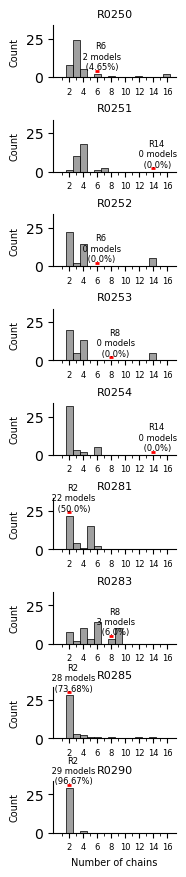

In [4]:
import numpy as np
g=sns.displot(stoch_df, x="num_chains", row="target", color='grey',height=1,aspect=2,
              bins=np.array([x+0.5 for x in range(0,17)]))
# TODO plot the gt
for i,(target,gt) in enumerate(gt_num_chains.items()):
    num_gt = ((stoch_df.target==target)&(stoch_df.num_chains==gt)).sum()
    num_total = (stoch_df.target==target).sum()
    g.axes.flat[i].hlines(num_gt+2,
                          gt-0.25,gt+0.25,"red",linewidth=2)
    g.axes.flat[i].text(gt+0.5,num_gt+3,
                       f'R{gt}\n {num_gt} models\n ({round(100*num_gt/num_total,2)}%)',
                       ha='center',size=6)
    print(g.axes.flat[i].get_title())
    g.axes.flat[i].set_title(target,size=8)
    g.axes.flat[i].set_ylabel('Count',size=7)
    g.axes.flat[i].set_xlabel('Number of chains',size=7)
    g.axes.flat[i].set_xticks(range(2,17,2))
    g.axes.flat[i].set_xticks(range(1,17,2),minor=True)
    g.axes.flat[i].set_xticklabels([x for x in range(2,17,2)],size=6)
    g.axes.flat[i].tick_params(labelbottom=True)
# label x axis for every

(-0.5, 8.5)


(0.0, 20.0)

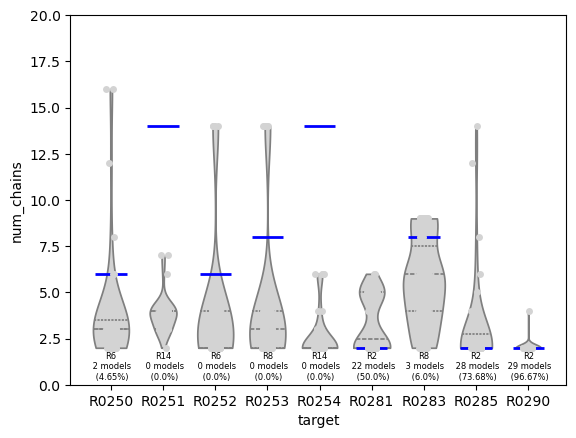

In [95]:
g = sns.violinplot(stoch_df,y="num_chains",x="target",cut=0, inner="quart",color='lightgrey',width=0.8,density_norm='count')
print(g.get_xlim())
g = sns.stripplot(stoch_df,y="num_chains",x="target",color='lightgrey')

for i,(target,gt) in enumerate(gt_num_chains.items()):
    num_gt = ((stoch_df.target==target)&(stoch_df.num_chains==gt)).sum()
    num_total = (stoch_df.target==target).sum()
    g.hlines(gt,i-0.3,i+0.3,"blue",linewidth=2)
    g.text(i,0.3,
                       f'R{gt}\n {num_gt} models\n ({round(100*num_gt/num_total,2)}%)',
                       ha='center',size=6)
g.set_ylim(0,20)

In [3]:
sym_df = pd.read_csv('casp16_sym_round1_rna-homomultimers.csv',na_values=[' '])
sym_df['target'] = sym_df.model.apply(lambda z: z.split('TS')[0])

# technically should check axis of smaller symmetries to confirm they are indeed subset...
def get_highest_symettry(row,rmsd_cutoff=15):
    if row.symmetries != row.symmetries:
        return 'c1'
    syms = row.symmetries.split()
    rmsds = row.rmsds.split()
    val_syms = [s for s,r in zip(syms,rmsds) if float(r)<rmsd_cutoff]
    current_highest_sym = 'c1'
    for sym in val_syms:
        if int(sym[1:]) > int(current_highest_sym[1:]):
            current_highest_sym = sym
        elif int(sym[1:]) == int(current_highest_sym[1:]) and sym[0] == 'd':
            current_highest_sym = sym
    return current_highest_sym

sym_df['sym'] = sym_df.apply(get_highest_symettry,axis=1)
sym_order = ['d7' ,'c14','c7','d4', 'c8', 'd3','c6', 'd2', 'c4' ,'c3','c2','c1'][::-1]
sym_df['sym'] = sym_df.sym.astype("category")
sym_df['sym'] = sym_df.sym.cat.set_categories(sym_order)
sym_df = sym_df.sort_values(['sym','target'])
target_order = ['R1250', 'R1251', 'R1252', 'R1253v1', 'R1253v2', 'R1254', 'R1281', 'R1283v2',
 'R1283v3', 'R1285', 'R1290']
# TODO check what is reasonable cutoff
sym_df.to_csv('casp16_rnamultimer_sym_round1.csv',index=False)

In [156]:
sym_df

,model,symmetries,rmsds,target,sym
0,R1250TS028_1o_simple,NaN,NaN,R1250,c1
1,R1250TS028_2o_simple,NaN,NaN,R1250,c1
2,R1250TS028_3o_simple,NaN,NaN,R1250,c1
3,R1250TS028_4o_simple,NaN,NaN,R1250,c1
4,R1250TS028_5o_simple,NaN,NaN,R1250,c1
...,...,...,...,...,...
224,R1254TS338_2o,d7 c7 c3 c2 c2 c2 c2 c2 c2 c2,9.813930 10.214366 25.614253 4.039882 9.23893...,R1254,d7
226,R1254TS338_4o,d7 c7 c3 c2 c2 c2 c2 c2 c2 c2,5.599773 5.828186 24.480883 3.348932 5.674235...,R1254,d7
227,R1254TS338_5o,d7 c7 c3 c2 c2 c2 c2 c2 c2 c2,10.023809 10.431650 34.869789 7.790669 9.4604...,R1254,d7
240,R1254TS481_3o,d7 c7 c3 c2 c2 c2 c2 c2 c2 c2,1.023574 1.065370 49.947832 0.001078 0.605173...,R1254,d7


In [157]:
print(sym_df.target.unique())
print(sym_df.sym.unique())

['R1250' 'R1251' 'R1252' 'R1253v1' 'R1253v2' 'R1254' 'R1281' 'R1283v2'
 'R1283v3' 'R1285' 'R1290']
['c1', 'c2', 'c3', 'c4', 'd2', ..., 'c8', 'd4', 'c7', 'c14', 'd7']
Length: 12
Categories (12, object): ['c1', 'c2', 'c3', 'c4', ..., 'd4', 'c7', 'c14', 'd7']


1

<ipython-input-165-7aa67bb58007>:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.axes.flat[i].set_xticklabels(sym_order,size=6)


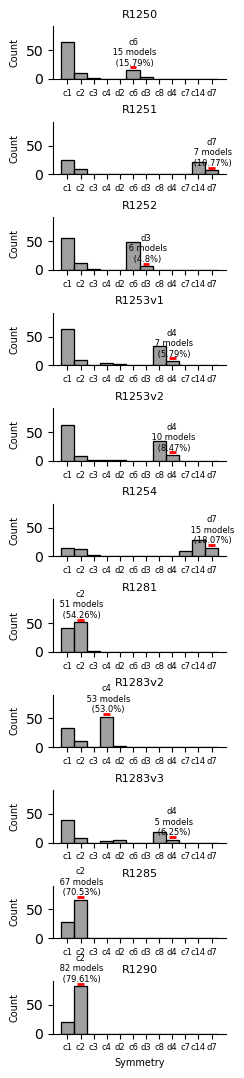

In [165]:
g=sns.displot(sym_df, x="sym", row="target", color='grey',
              height=1,aspect=2.5,row_order=target_order)
refsyms = {'R1250':sym_order.index('c6'),
        'R1251':sym_order.index('d7'),
        'R1252':sym_order.index('d3'),
        'R1253v1':sym_order.index('d4'), 
        'R1253v2':sym_order.index('d4'), 
        'R1254':sym_order.index('d7'), 
        'R1281':sym_order.index('c2'), # TODO check I get same result on natives
        'R1283v2':sym_order.index('c4'),
        'R1283v3':sym_order.index('d4'), 
        'R1285':sym_order.index('c2'), 
        'R1290':sym_order.index('c2')}
for i,(target,gt) in enumerate(refsyms.items()):
    num_gt = ((sym_df.target==target)&(sym_df.sym==sym_order[gt])).sum()
    num_total = (sym_df.target==target).sum()
    g.axes.flat[i].hlines(num_gt+5,
                          gt-0.25,gt+0.25,"red",linewidth=2)
    g.axes.flat[i].text(gt,num_gt+8,
                       f'{sym_order[gt]}\n {num_gt} models\n ({round(100*num_gt/num_total,2)}%)',
                       ha='center',size=6)
    #print(g.axes.flat[i].get_title())
    g.axes.flat[i].set_title(target,size=8)
    g.axes.flat[i].set_ylabel('Count',size=7)
    g.axes.flat[i].set_xlabel('Symmetry',size=7)
    #g.axes.flat[i].set_xticks(range(2,17,2))
    #g.axes.flat[i].set_xticks(range(1,17,2),minor=True)
    #g.axes.flat[i].set_xticklabels([x for x in range(2,17,2)],size=6)
    g.axes.flat[i].set_xticklabels(sym_order,size=6)
    g.axes.flat[i].tick_params(labelbottom=True)